In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
os.chdir("..")

In [3]:
print(os.getcwd())

c:\Users\ryuk7\Desktop\Projects\Frontier-AI\02_MLP


In [4]:
import numpy as np
from src.inference import load_weights
from src.dataset import load_data
from src.model import NN
import matplotlib.pyplot as plt

In [5]:
model = NN()
W1,b1,W2,b2 = load_weights()
model.W1,model.b1,model.W2,model.b2 = W1,b1,W2,b2

In [6]:
X_train,X_test,y_train,y_test = load_data("data")


In [22]:
y_test = y_test.T

In [28]:
wrongs = 0
for i in range(10000):
    if model.infer(X_test[:,i].reshape(-1,1)) != np.argmax(y_test[i]):
        print(i)
        wrongs+=1


8
63
66
115
149
195
233
247
259
290
300
307
320
321
324
340
352
358
362
366
381
412
445
448
449
495
507
542
543
551
565
569
578
591
610
619
628
659
684
691
692
707
717
720
740
786
839
844
877
882
898
924
938
939
947
950
951
956
965
982
1003
1014
1032
1039
1044
1055
1062
1082
1096
1107
1112
1114
1124
1128
1173
1178
1181
1182
1191
1192
1194
1198
1202
1204
1206
1226
1228
1232
1233
1242
1247
1252
1253
1256
1260
1283
1310
1319
1325
1326
1328
1337
1364
1378
1393
1413
1414
1422
1433
1441
1444
1464
1466
1467
1494
1500
1522
1525
1527
1530
1549
1553
1581
1587
1607
1634
1681
1696
1709
1717
1721
1737
1740
1751
1754
1759
1773
1782
1790
1832
1850
1878
1899
1901
1930
1938
1941
1952
1969
1970
1982
1984
2016
2024
2040
2043
2044
2053
2070
2098
2099
2105
2109
2115
2118
2121
2129
2130
2131
2135
2174
2182
2185
2186
2189
2215
2266
2272
2293
2305
2312
2325
2326
2329
2369
2371
2387
2393
2395
2406
2422
2425
2433
2488
2514
2526
2545
2560
2607
2610
2630
2648
2654
2713
2771
2780
2810
2836
2853
2877
2896
2907
2925

2


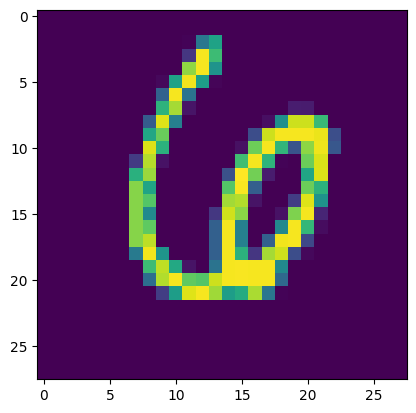

In [34]:
X_test_mod = X_test.T.reshape((10000,28,28))
plt.imshow(X_test_mod[66])
print(model.infer(X_test[:,66].reshape(-1,1)))

In [ ]:
model.infer(X_test)

In [42]:
np.min(model.W2)

np.float64(-1.5165791322080093)

In [61]:
def patch(W):
    N = []
    for i in range(10):
        Wi = (W[i]-W[i].min())/(W[i].max()-W[i].min())
        N.append(Wi)
    return N

In [73]:
mod_W1 = model.W1.reshape(10,28,28)
N = np.array(patch(mod_W1))

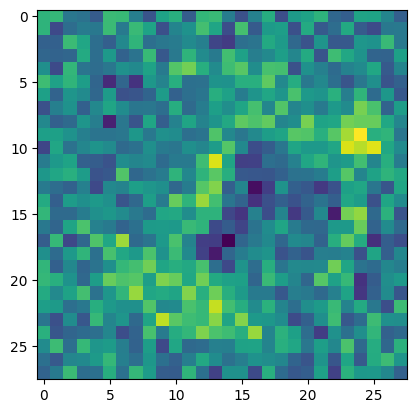

In [ ]:
N0 = N[0]
N1 = N[1]
N2 = N[2]
N3 = N[3]
N4 = N[4]
N5 = N[5]
N6 = N[6]
N7 = N[7]
N8 = N[8]

In [77]:
mod = model.W2
N0 = np.sum(np.dot(mod[0].reshape(1,-1),N))

ValueError: shapes (1,10) and (10,28,28) not aligned: 10 (dim 1) != 28 (dim 1)

In [69]:
model.b1

array([[-0.15406728],
       [ 0.03047826],
       [ 0.17979557],
       [ 0.0987625 ],
       [ 0.02350965],
       [-0.14221783],
       [ 0.07432998],
       [ 0.55032224],
       [ 0.53341477],
       [ 0.42305128]])

(10, 28, 28)


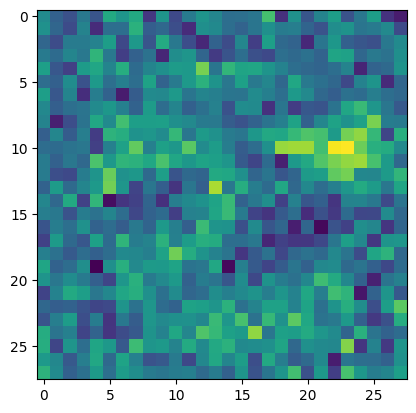

In [106]:
patches = (model.W2@model.W1).reshape((10,28,28))

print(patches.shape)
plt.imshow(patches[8])

In [107]:
wrongs = 0
for i in range(10000):
    if model.infer(X_test[:,i].reshape(-1,1)) != np.argmax(y_test[i]):
        print(i)
        wrongs+=1


8
63
66
115
149
195
233
247
259
290
300
307
320
321
324
340
352
358
362
366
381
412
445
448
449
495
507
542
543
551
565
569
578
591
610
619
628
659
684
691
692
707
717
720
740
786
839
844
877
882
898
924
938
939
947
950
951
956
965
982
1003
1014
1032
1039
1044
1055
1062
1082
1096
1107
1112
1114
1124
1128
1173
1178
1181
1182
1191
1192
1194
1198
1202
1204
1206
1226
1228
1232
1233
1242
1247
1252
1253
1256
1260
1283
1310
1319
1325
1326
1328
1337
1364
1378
1393
1413
1414
1422
1433
1441
1444
1464
1466
1467
1494
1500
1522
1525
1527
1530
1549
1553
1581
1587
1607
1634
1681
1696
1709
1717
1721
1737
1740
1751
1754
1759
1773
1782
1790
1832
1850
1878
1899
1901
1930
1938
1941
1952
1969
1970
1982
1984
2016
2024
2040
2043
2044
2053
2070
2098
2099
2105
2109
2115
2118
2121
2129
2130
2131
2135
2174
2182
2185
2186
2189
2215
2266
2272
2293
2305
2312
2325
2326
2329
2369
2371
2387
2393
2395
2406
2422
2425
2433
2488
2514
2526
2545
2560
2607
2610
2630
2648
2654
2713
2771
2780
2810
2836
2853
2877
2896
2907
2925

In [108]:
wrongs

580